# find_damage.ipynb

In [212]:
import sqlite3
from icecream import ic
from shapely import wkb
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [213]:
db_path = 'test.db'

In [214]:
conn = sqlite3.connect(db_path)   
conn.enable_load_extension(True)
conn.load_extension('mod_spatialite')
conn.execute("SELECT InitSpatialMetaData(1);")
cursor = conn.cursor()

InitSpatiaMetaData() error:"table spatial_ref_sys already exists"


In [215]:
cursor.execute('SELECT * FROM v_tree_poly')
# Retrieve the BLOB data
cursor.execute("SELECT image_width, image_height, AsBinary(tree_poly) FROM v_tree_poly WHERE tree_id = 1")
image_width, image_height, blob = cursor.fetchone()
poly = wkb.loads(blob)
coords = np.array(poly.exterior.coords)
points = coords.astype(np.int32).reshape((-1, 1, 2))
points = np.abs(points)
ic(points.dtype)
ic(points.shape)
ic(points);

ic| points.dtype: dtype('int32')
ic| points.shape: (1084, 1, 2)
ic| points: array([[[486, 677]],
            
                   [[486, 682]],
            
                   [[485, 683]],
            
                   ...,
            
                   [[488, 678]],
            
                   [[487, 678]],
            
                   [[486, 677]]], shape=(1084, 1, 2), dtype=int32)


In [216]:
mask = np.zeros((image_width, image_height), dtype=np.uint8)
cv2.fillPoly(mask, [points], 255)
ic(np.sum(mask))
ic(mask.shape);


ic| np.sum(mask): np.uint64(7588800)
ic| mask.shape: (1366, 2048)


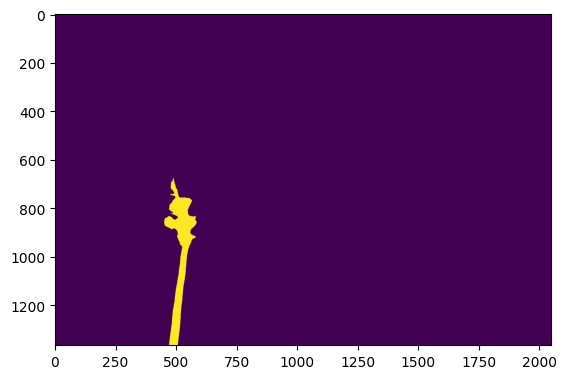

In [222]:
plt.imshow(mask);

# cv2.imshow("Polygon Mask", mask)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


In [218]:
conn.close()